In [25]:
import warnings
warnings.filterwarnings("ignore")

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [27]:
df = pd.read_csv('datasets/Tweets.csv')

df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [28]:
texts = df['selected_text']
texts = texts.fillna("")
texts = texts.astype(str)

labels = df['sentiment']
encoder = LabelEncoder()
labels = encoder.fit_transform(labels)


In [29]:
tokenizer = Tokenizer(num_words=8000)
tokenizer.fit_on_texts(texts)

X = tokenizer.texts_to_sequences(texts)
X = pad_sequences(X, maxlen=50)

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, labels, test_size=0.2, random_state=42
)

In [31]:
X_train = np.array(X_train, dtype='int32')
X_test = np.array(X_test, dtype='int32')
y_train = np.array(y_train, dtype='int32')
y_test = np.array(y_test, dtype='int32')

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout

def build_rnn():
    model = Sequential([
        Embedding(input_dim=8000, output_dim=64, input_length=50),
        SimpleRNN(64),
        Dense(32, activation='relu'),
        Dense(3, activation='softmax')
    ])
    return model

def build_lstm():
    model = Sequential([
        Embedding(input_dim=8000, output_dim=64, input_length=50),
        LSTM(64),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dense(3, activation='softmax')
    ])
    return model

# Store models in list
models = [
    ("RNN", build_rnn()),
    ("LSTM", build_lstm())
]

In [33]:
histories = {}

for name, model in models:
    print(f"\n Training {name} model...\n")
    
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    
    history = model.fit(
        X_train, y_train,
        epochs=5,
        batch_size=32,
        validation_split=0.1
    )
    
    histories[name] = history


 Training RNN model...

Epoch 1/5
619/619 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7499 - loss: 0.6141 - val_accuracy: 0.8236 - val_loss: 0.4727
Epoch 2/5
619/619 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8676 - loss: 0.3616 - val_accuracy: 0.8354 - val_loss: 0.4579
Epoch 3/5
619/619 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9119 - loss: 0.2438 - val_accuracy: 0.8204 - val_loss: 0.5181
Epoch 4/5
619/619 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9430 - loss: 0.1608 - val_accuracy: 0.8140 - val_loss: 0.5872
Epoch 5/5
619/619 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9587 - loss: 0.1165 - val_accuracy: 0.7917 - val_loss: 0.6742

 Training LSTM model...

Epoch 1/5
619/619 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.7076 - loss: 0.6739 - val_accuracy: 0.8281 - val_loss: 0.4601
Epoch 2/5
619/619 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.8539 - loss: 0.3878 - val_accuracy: 0.8340 - val_loss: 0.4553
Epoch 3/5
619/619 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/ste

In [36]:
for name, model in models:
    print(f"\n Evaluating {name} model:")
    loss, acc = model.evaluate(X_test, y_test)
    print(f"{name} Accuracy: {acc:.4f}")


 Evaluating RNN model:
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8010 - loss: 0.6901
RNN Accuracy: 0.8010

 Evaluating LSTM model:
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8357 - loss: 0.5296
LSTM Accuracy: 0.8357


In [ ]:
def predict(text, model):
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=50)
    pred = model.predict(padded)
    return encoder.inverse_transform([pred.argmax()])

print(predict("Worst flight ever", models[1][1]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
['negative']


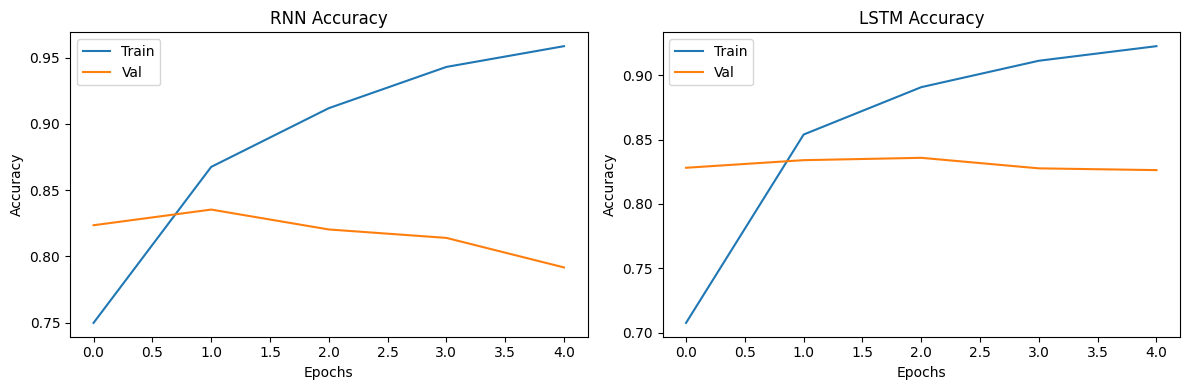

In [40]:
import matplotlib.pyplot as plt

n = len(histories)

plt.figure(figsize=(6*n, 4))  # adjust width dynamically

for i, (name, history) in enumerate(histories.items(), 1):
    plt.subplot(1, n, i)
    
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    
    plt.title(f'{name} Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(['Train', 'Val'])

plt.tight_layout()
plt.show()

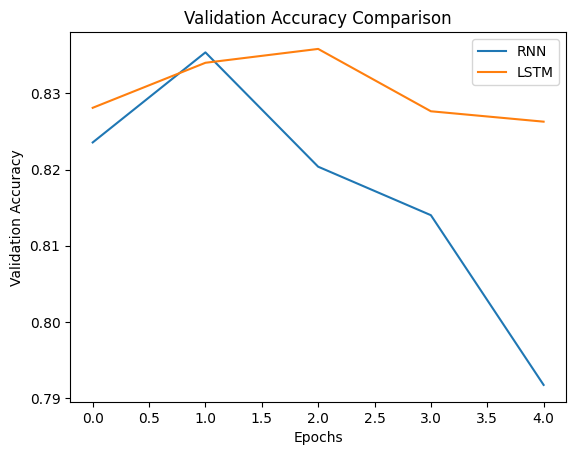

In [38]:
plt.figure()

for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=name)

plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()

plt.show()